# MS 3313 — Comprehensive Final Exam

## Modules 1–5 (R Basics → ML Basics → ANOVA/MANOVA → Dimension Reduction → KNN → Factor & Conjoint → Clustering → Discriminant Analysis)

**Course:** MS3313  
**Final:** Cumulative — covers every technical area in the lecture notebooks.

---

### Instructions

This notebook contains **eight questions**. For each question:

- Code cells already define the **dataset name**, **input variable name (X)**, and **output / model object name** you must use. **Do not rename them — graders look for these specific names.**
- Wherever you see `# YOUR CODE HERE — delete this comment when you add your code`, replace that line with your solution.
- Wherever you see `NULL    # replace NULL with your code`, replace `NULL` with your working expression.
- After each question, an **analysis answer** markdown cell is provided. Replace `*Your answer here*` with your written interpretation (3–6 sentences).
- All datasets come from the **`mlba`** package — no external CSVs needed.
- Use `set.seed(42)` whenever a partition / random start is required (already provided).

### Required object names

| Q | Module | Dataframe | Inputs (X) / Model | Output / Result |
|---|--------|-----------|--------------------|-----------------|
| 1 | M1 — ML basics | `air.df` | `X_air`, `train.df`, `valid.df`, `fare.lm` | `Y_fare_pred`, `rmse_fare`, `mae_fare`, `mape_fare` |
| 2 | M2 — ANOVA/MANOVA | `flights.df` | `aov_dep`, `tukey_dep`, `levene_dep`, `manova_flights` | (built-in objects) |
| 3 | M3 — Dimension reduction | `uni.df` | `pca_cov`, `pca_cor` | `n_pcs_kaiser` |
| 4 | M4.0 — KNN | `tayko.df` | `tayko_train`, `tayko_valid`, `train_X_tayko`, `valid_X_tayko`, `train_y_tayko`, `valid_y_tayko` | `acc_tayko`, `best_k_tayko`, `Y_tayko_pred`, `cm_tayko` |
| 5 | M4.1a — Factor analysis | `books.df` | `X_books_norm`, `fa_books` | `kmo_books`, `bartlett_books` |
| 6 | M4.1b — Conjoint | `profiles.df` | `cj_lm`, `partworth` | `attr_importance` |
| 7 | M5.0 — Clustering | `ewa.df` | `X_ewa_norm`, `d_ewa`, `hc_ewa`, `km_ewa` | `Y_ewa_hier`, `Y_ewa_km`, `ewa_profile` |
| 8 | M5.1 — LDA | `banks.df` | `X_banks`, `Y_banks`, `lda_banks` | `Y_banks_pred`, `cm_banks`, `accuracy_banks`, `new_bank`, `pred_new_bank` |

---


## Setup: Load Required Libraries

Run this cell as-is. Do **not** modify.

In [1]:
suppressPackageStartupMessages({
  library(mlba)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(ggplot2)
  library(caret)
  library(class)         # knn()
  library(MASS)          # lda()
  library(psych)         # KMO, cortest.bartlett, fa.parallel, fa
  library(GPArotation)
  library(car)           # leveneTest
  library(cluster)
  library(factoextra)
  library(conjoint)
  library(fastDummies)
  library(IRdisplay)
})

# dplyr::select wins after MASS is loaded
select <- dplyr::select

set.seed(42)
options(scipen = 999, digits = 4)


## Plot rendering — make charts legible

The default Jupyter R kernel often renders ggplot / `factoextra` figures
with a device that produces tiny or blurry axis text. **Every plot in this
exam must be drawn through a cairo PNG device** so axes, titles, and
legends are readable. The pattern is already provided in each plotting
cell — you only have to drop your plotting expression into the marked
spot:

```r
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 600, res = 120,
    type = "cairo", family = "sans")

print(
  NULL    # replace NULL with your ggplot / fviz_* / plot(...) call
)

dev.off()
IRdisplay::display_png(file = tmp_file)
```

**Hints**

* For `print({ ... })` you may pass a single ggplot or `fviz_*` object.
* For base-graphics calls (e.g., `plot(hc); rect.hclust(...)`) put the
  drawing commands *between* `png(...)` and `dev.off()` — no `print()` needed.
* Keep `res = 120` and `family = "sans"` so the rendered fonts match the
  rest of the exam.


---
## Question 1 — Module 1: Multiple Linear Regression on Airfares

**Dataset:** `mlba::Airfares` (638 routes × 18 variables)

**Inputs (X):** all route variables after dropping the four ID/text columns
(`S_CODE`, `S_CITY`, `E_CODE`, `E_CITY`) and dummy-encoding the four categorical
predictors (`VACATION`, `SW`, `SLOT`, `GATE`).

**Output (Y):** `FARE` (average fare in dollars).

**Tasks:**
1. Load the data, drop the four ID columns, and dummy-encode the four categoricals → store the cleaned data in `air.df` and the predictor matrix in `X_air`
2. Partition 60% training / 40% validation with `set.seed(42)` → store in `train.df` and `valid.df`
3. Fit a multiple linear regression `FARE ~ .` on the training set → store in `fare.lm`
4. Predict on the validation set → store predictions in `Y_fare_pred`
5. Compute validation **RMSE**, **MAE**, and **MAPE** → store in `rmse_fare`, `mae_fare`, `mape_fare`
6. Identify the two predictors with the largest absolute *t*-statistic → store in `top2_air`
7. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load Data, Drop ID Columns, Dummy-Encode

Use `air.df` for the cleaned dataframe and `X_air` for the predictor matrix.

In [6]:
data("Airfares")

air.df <- Airfares[ , !(names(Airfares) %in% c("S_CODE", "S_CITY", "E_CODE", "E_CITY"))]

dummy <- model.matrix(~ VACATION + SW + SLOT + GATE - 1, data = air.df)

air.df <- cbind(air.df[ , !(names(air.df) %in% c("VACATION", "SW", "SLOT", "GATE"))], dummy)
X_air  <- as.matrix(air.df[ , names(air.df) != "FARE"])

cat("Rows:", nrow(air.df), " Columns:", ncol(air.df), "\n")
str(air.df)


Rows: 638  Columns: 15 
'data.frame':	638 obs. of  15 variables:
 $ COUPON     : num  1 1.06 1.06 1.06 1.06 1.01 1.28 1.15 1.33 1.6 ...
 $ NEW        : int  3 3 3 3 3 3 3 3 3 2 ...
 $ HI         : num  5292 5419 9185 2657 2657 ...
 $ S_INCOME   : num  28637 26993 30124 29260 29260 ...
 $ E_INCOME   : num  21112 29838 29838 29838 29838 ...
 $ S_POP      : int  3036732 3532657 5787293 7830332 7830332 2230955 3036732 1440377 3770125 1694803 ...
 $ E_POP      : int  205711 7145897 7145897 7145897 7145897 7145897 7145897 7145897 7145897 7145897 ...
 $ DISTANCE   : int  312 576 364 612 612 309 1220 921 1249 964 ...
 $ PAX        : int  7864 8820 6452 25144 25144 13386 4625 5512 7811 4657 ...
 $ FARE       : num  64.1 174.5 207.8 85.5 85.5 ...
 $ VACATIONNo : num  1 1 1 1 1 1 1 0 1 1 ...
 $ VACATIONYes: num  0 0 0 0 0 0 0 1 0 0 ...
 $ SWYes      : num  1 0 0 1 1 1 0 1 1 1 ...
 $ SLOTFree   : num  1 1 1 0 1 1 1 1 1 1 ...
 $ GATEFree   : num  1 1 1 1 1 1 1 1 1 1 ...


### Step 2 — 60/40 Train/Validation Partition

Store the partitions in `train.df` and `valid.df`.

In [ ]:
set.seed(42)

train_idx <- sample(1:nrow(air.df), size = floor(0.6 * nrow(air.df)))
train.df  <- air.df[train_idx, ]
valid.df  <- air.df[-train_idx, ]

cat("train rows:", nrow(train.df), " valid rows:", nrow(valid.df), "\n")


train rows: 382  valid rows: 256 


### Step 3 — Fit the Multiple Linear Regression

Fit `FARE ~ .` on the training set; store the model in `fare.lm`.

In [8]:

fare.lm <- lm(FARE ~ ., data = train.df)

summary(fare.lm)



Call:
lm(formula = FARE ~ ., data = train.df)

Residuals:
   Min     1Q Median     3Q    Max 
-99.82 -23.15  -3.16  22.80 105.85 

Coefficients: (1 not defined because of singularities)
                 Estimate    Std. Error t value             Pr(>|t|)    
(Intercept) -39.039481330  36.142580262   -1.08               0.2808    
COUPON       25.847265367  16.472312861    1.57               0.1175    
NEW          -2.173578494   2.623328899   -0.83               0.4079    
HI            0.008342867   0.001328067    6.28    0.000000000944278 ***
S_INCOME      0.000884957   0.000699365    1.27               0.2065    
E_INCOME      0.001367974   0.000487048    2.81               0.0052 ** 
S_POP         0.000003677   0.000000881    4.17    0.000037450776099 ***
E_POP         0.000004415   0.000001006    4.39    0.000014918750109 ***
DISTANCE      0.067187479   0.004770719   14.08 < 0.0000000000000002 ***
PAX          -0.000706558   0.000197688   -3.57               0.0004 ***
VACATIONNo

### Step 4 — Predict on the Validation Set

Store the predicted fares in `Y_fare_pred`.

In [9]:

Y_fare_pred <- predict(fare.lm, newdata = valid.df)

head(Y_fare_pred)


1      4      5      6      7      8 
 69.40 133.88 117.67  87.16 232.20 114.78

### Step 5 — Compute Validation RMSE, MAE, and MAPE

Store the metrics in `rmse_fare`, `mae_fare`, `mape_fare`.

In [10]:
actuals <- valid.df$FARE

rmse_fare <- sqrt(mean((actuals - Y_fare_pred)^2))
mae_fare  <- mean(abs(actuals - Y_fare_pred))
mape_fare <- mean(abs((actuals - Y_fare_pred) / actuals)) * 100

cat(sprintf("RMSE = %.3f\nMAE  = %.3f\nMAPE = %.3f%%\n",
            rmse_fare, mae_fare, mape_fare))


RMSE = 34.157
MAE  = 26.686
MAPE = 20.506%


### Step 6 — Top 2 Most Influential Predictors (Largest |t|)

Store the two top rows of the coefficient table in `top2_air`.

In [ ]:
coef_table <- summary(fare.lm)$coefficients[-1, ]

top2_air <- coef_table[order(abs(coef_table[, "t value"]), decreasing = TRUE)[1:2], ]
top2_air


,Estimate,Std. Error,t value,Pr(>|t|)
DISTANCE,0.06719,0.004771,14.083,0.000000000000000000000000000000000002479
VACATIONNo,38.55367,4.868524,7.919,0.000000000000028607342042521423053973911


### Question 1 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

---


## Question 2 — Module 2: ANOVA & MANOVA on Flight Delays

**Dataset:** `mlba::FlightDelays` (2,201 flights × 13 variables)

**Tasks:**
1. Load the data, convert `CARRIER`, `DAY_WEEK`, and `Flight.Status` to factors → store in `flights.df`
2. Run a one-way **ANOVA**: does `CRS_DEP_TIME` differ across `CARRIER`? → store the model in `aov_dep`
3. Run **Tukey HSD** post-hoc on `aov_dep` → store in `tukey_dep`
4. Test homogeneity of variance with **Levene's test** (`car::leveneTest`) → store in `levene_dep`
5. Run a one-way **MANOVA**: do `CRS_DEP_TIME` and `DISTANCE` jointly differ across `DAY_WEEK`? → store in `manova_flights`; report **Pillai's trace**
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load Data and Set Factor Types

Store the cleaned dataframe in `flights.df`.

In [12]:
data("FlightDelays")

flights.df <- FlightDelays
flights.df$CARRIER      <- as.factor(flights.df$CARRIER)
flights.df$DAY_WEEK     <- as.factor(flights.df$DAY_WEEK)
flights.df$Flight.Status <- as.factor(flights.df$Flight.Status)

cat("n =", nrow(flights.df), "  carriers =", nlevels(flights.df$CARRIER), "\n")
table(flights.df$CARRIER)


n = 2201   carriers = 8 



 CO  DH  DL  MQ  OH  RU  UA  US 
 94 551 388 295  30 408  31 404 

### Step 2 — One-Way ANOVA: `CRS_DEP_TIME ~ CARRIER`

Store the ANOVA model in `aov_dep`.

In [13]:

aov_dep <- aov(CRS_DEP_TIME ~ CARRIER, data = flights.df)
summary(aov_dep)


              Df    Sum Sq Mean Sq F value           Pr(>F)    
CARRIER        7  13475003 1925000    10.6 0.00000000000036 ***
Residuals   2193 398424008  181680                             
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### Step 3 — Tukey HSD Post-Hoc

Store the result in `tukey_dep` and show the five smallest adjusted *p*-values.

In [14]:


tukey_dep <- TukeyHSD(aov_dep)

head(tukey_dep$CARRIER[order(tukey_dep$CARRIER[,"p adj"]), ], 5)


,diff,lwr,upr,p adj
UA-DH,-598.7,-837.4,-360.0,0.00000000006457
UA-DL,-519.4,-760.7,-278.0,0.00000000236566
US-UA,513.4,272.4,754.4,0.00000000360199
UA-CO,-569.5,-837.3,-301.7,0.00000000387473
UA-RU,-494.5,-735.4,-253.6,0.00000001596055


### Step 4 — Levene's Test for Homogeneity of Variance

Store the test result in `levene_dep`.

In [ ]:

levene_dep <- leveneTest(CRS_DEP_TIME ~ CARRIER, data = flights.df)
levene_dep


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,7,19.69,0.00000000000000000000000009907
,2193,NA,NA


### Step 5 — One-Way MANOVA: `cbind(CRS_DEP_TIME, DISTANCE) ~ DAY_WEEK`

Store the MANOVA in `manova_flights` and report Pillai's trace.

In [16]:

manova_flights <- manova(cbind(CRS_DEP_TIME, DISTANCE) ~ DAY_WEEK, data = flights.df)

summary(manova_flights, test = "Pillai")
summary.aov(manova_flights)   # univariate follow-ups


            Df  Pillai approx F num Df den Df Pr(>F)
DAY_WEEK     6 0.00786     1.44     12   4388   0.14
Residuals 2194                                      

 Response CRS_DEP_TIME :
              Df    Sum Sq Mean Sq F value Pr(>F)  
DAY_WEEK       6   2822921  470487    2.52  0.019 *
Residuals   2194 409076090  186452                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

 Response DISTANCE :
              Df Sum Sq Mean Sq F value Pr(>F)
DAY_WEEK       6    382    63.7    0.36   0.91
Residuals   2194 389761   177.6               


### Question 2 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

---


## Question 3 — Module 3: PCA on Universities

**Dataset:** `mlba::Universities` (1,302 universities × 20 variables)

**Inputs (X):** the 17 numeric metrics — drop `College.Name`, `State`, and the
binary public/private flag, then drop rows with any `NA`.

**Tasks:**
1. Load the data, drop the three non-numeric columns, drop rows with any `NA` → store in `uni.df`
2. Run PCA on the **covariance** matrix (raw scale) → store in `pca_cov`
3. Run PCA on the **correlation** matrix (`scale. = TRUE`) → store in `pca_cor`
4. Apply the **Kaiser rule** (eigenvalue ≥ 1) on `pca_cor` → store the count in `n_pcs_kaiser`; report the cumulative variance explained
5. Plot the **scree plot** and the **PC1–PC2 biplot** of `pca_cor`
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load and Clean the Data

Store the cleaned numeric dataframe in `uni.df`.

In [ ]:

data("Universities")

uni.df <- Universities[ , !(names(Universities) %in% c("College.Name", "State", "Public..1...Private..2."))]

uni.df <- na.omit(uni.df)


cat("n =", nrow(uni.df), "  p =", ncol(uni.df), "\n")


n = 471   p = 17 


### Step 2 — PCA on the Covariance Matrix

Store in `pca_cov`. (Use `prcomp` with `scale. = FALSE`.)

In [18]:

pca_cov <- prcomp(uni.df, scale. = FALSE)
round(summary(pca_cov)$importance[, 1:5], 4)


,PC1,PC2,PC3,PC4,PC5
Standard deviation,7430.9140,5987.9890,1854.6412,1192.5293,967.4279
Proportion of Variance,0.5614,0.3645,0.0350,0.0145,0.0095
Cumulative Proportion,0.5614,0.9259,0.9609,0.9753,0.9848


### Step 3 — PCA on the Correlation Matrix (Standardized)

Store in `pca_cor`. (Use `prcomp` with `scale. = TRUE`.)

In [19]:

pca_cor <- prcomp(uni.df, scale. = TRUE)
round(summary(pca_cor)$importance[, 1:6], 4)


,PC1,PC2,PC3,PC4,PC5,PC6
Standard deviation,2.2749,2.1426,1.0984,1.0325,0.9760,0.8728
Proportion of Variance,0.3044,0.2700,0.0710,0.0627,0.0560,0.0448
Cumulative Proportion,0.3044,0.5745,0.6454,0.7081,0.7642,0.8090


### Step 4 — Kaiser Rule

Store the number of components retained in `n_pcs_kaiser`.

In [ ]:

eig <- pca_cor$sdev^2
n_pcs_kaiser <- sum(eig >= 1)

cat("Kaiser keeps", n_pcs_kaiser, "PCs\n")
cat("Cumulative variance explained =",
    round(sum(eig[seq_len(n_pcs_kaiser)]) / sum(eig), 3), "\n")


Kaiser keeps 4 PCs
Cumulative variance explained = 0.708 


### Step 5 — Scree Plot and PC1–PC2 Biplot

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
“Ignoring empty aesthetic: `width`.”


agg_record_1033320285 
                    2

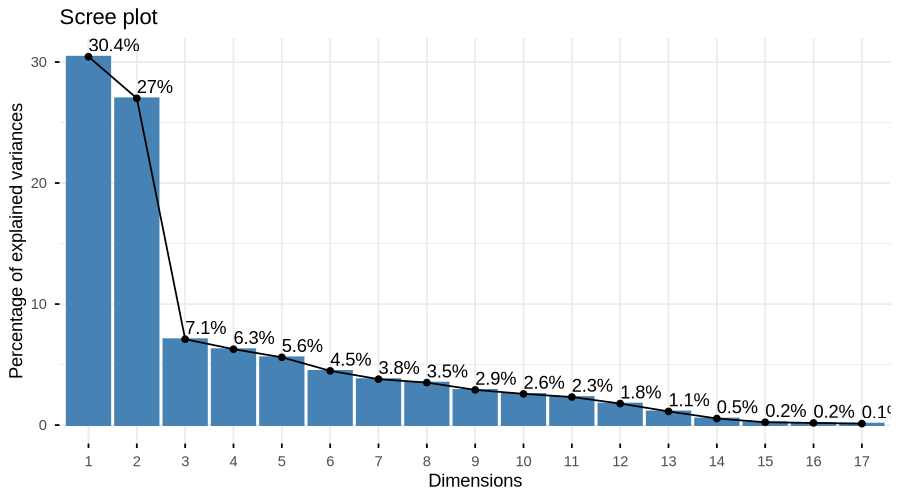

In [22]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 500, res = 120,
    type = "cairo", family = "sans")


print(
  fviz_eig(pca_cor, addlabels = TRUE, ncp = ncol(uni.df))
)

dev.off()
IRdisplay::display_png(file = tmp_file)


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>.”


agg_record_912923565 
                   2

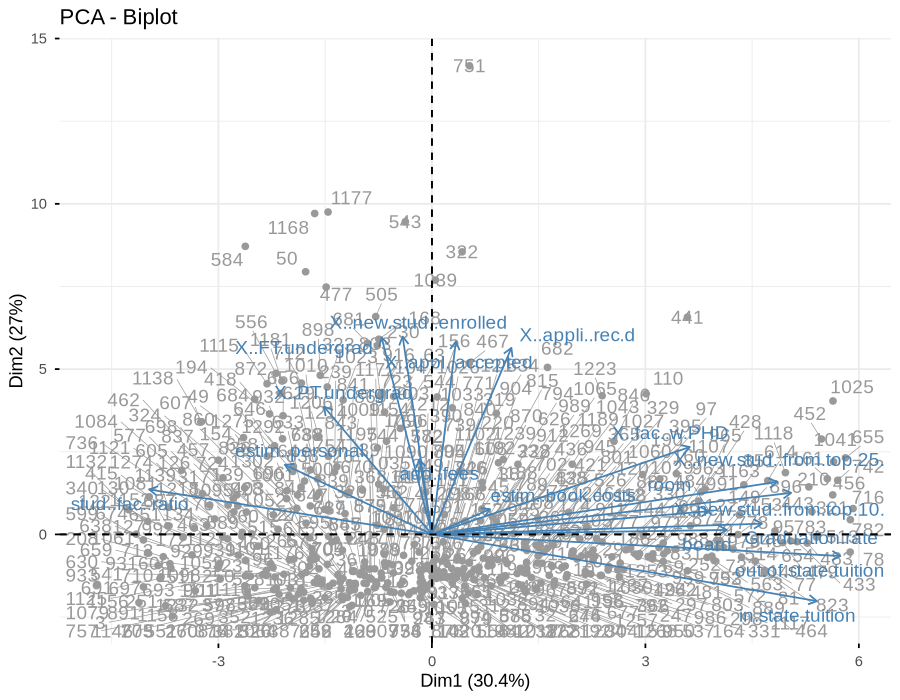

In [23]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 700, res = 120,
    type = "cairo", family = "sans")

# YOUR CODE HERE — delete this comment when you add your code
# Build a fviz_pca_biplot(...) plot of pca_cor inside print(...).

print(
  fviz_pca_biplot(pca_cor, repel = TRUE, col.var = "steelblue", col.ind = "grey60")
)

dev.off()
IRdisplay::display_png(file = tmp_file)


### Question 3 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

---


## Question 4 — Module 4.0: K-Nearest Neighbors on Tayko

**Dataset:** `mlba::Tayko` (2,000 catalog customers × 25 variables)

**Inputs (X):** all variables except `sequence_number` and `Spending`
(`Spending` is target leakage: `Spending > 0` ⇒ `Purchase = 1`).

**Output (Y):** `Purchase` as a factor with levels `c("No", "Yes")`.

**Tasks:**
1. Load the data, drop `sequence_number` and `Spending`, factor `Purchase` → store in `tayko.df`
2. Partition 60/40 with `set.seed(42)` → store in `tayko_train` and `tayko_valid`
3. Standardize using **training-set statistics only** (`caret::preProcess`) → store in `train_X_tayko`, `valid_X_tayko`, `train_y_tayko`, `valid_y_tayko`
4. Tune `k` over `1:15` using `class::knn` and validation accuracy → store the table in `acc_tayko` and the best `k` in `best_k_tayko`
5. Refit at `k = best_k_tayko`, store predictions in `Y_tayko_pred` and the confusion matrix in `cm_tayko`
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load and Clean the Data

Store in `tayko.df`. Make `Purchase` a factor with levels `c("No", "Yes")`.

In [2]:
tayko.df <- mlba::Tayko
tayko.df$sequence_number <- NULL
tayko.df$Spending <- NULL
tayko.df$Purchase <- factor(tayko.df$Purchase, levels = c(0, 1), labels = c("No", "Yes"))

cat("Rows:", nrow(tayko.df), "  Columns:", ncol(tayko.df), "\n")
table(tayko.df$Purchase)


Rows: 2000   Columns: 23 



  No  Yes 
1000 1000 

### Step 2 — 60/40 Partition

Store in `tayko_train` and `tayko_valid`.

In [3]:
set.seed(42)

train_idx  <- sample(1:nrow(tayko.df), 0.6 * nrow(tayko.df))
tayko_train <- tayko.df[train_idx, ]
tayko_valid <- tayko.df[-train_idx, ]

cat("train:", nrow(tayko_train), "  valid:", nrow(tayko_valid), "\n")


train: 1200   valid: 800 


### Step 3 — Standardize Predictors (Training Stats Only)

Store predictor matrices in `train_X_tayko`, `valid_X_tayko` and labels in
`train_y_tayko`, `valid_y_tayko`. Use `caret::preProcess(method = c("center","scale"))`.

In [4]:

pp_tayko <- preProcess(tayko_train[, -ncol(tayko_train)], method = c("center", "scale"))
train_X_tayko <- predict(pp_tayko, tayko_train[, -ncol(tayko_train)])
valid_X_tayko <- predict(pp_tayko, tayko_valid[, -ncol(tayko_valid)])
train_y_tayko <- tayko_train$Purchase
valid_y_tayko <- tayko_valid$Purchase


cat("Train means (should be ~0):\n"); print(round(colMeans(train_X_tayko), 3))


Train means (should be ~0):
                  US             source_a             source_c 
                   0                    0                    0 
            source_b             source_d             source_e 
                   0                    0                    0 
            source_m             source_o             source_h 
                   0                    0                    0 
            source_r             source_s             source_t 
                   0                    0                    0 
            source_u             source_p             source_x 
                   0                    0                    0 
            source_w                 Freq last_update_days_ago 
                   0                    0                    0 
X1st_update_days_ago            Web.order          Gender.male 
                   0                    0                    0 
      Address_is_res 
                   0 


### Step 4 — Tune `k` over 1..15

Store the per-k accuracy table in `acc_tayko` and the best `k` in `best_k_tayko`.

In [5]:
trControl <- trainControl(method = "cv", number = 5)

model <- train(Purchase ~ ., data = tayko_train,
               method = "knn",
               preProcess = c("center", "scale"),
               tuneGrid = expand.grid(k = 1:15),
               trControl = trControl)

model

acc_tayko    <- model$results[, c("k", "Accuracy")]
names(acc_tayko)[2] <- "accuracy"
best_k_tayko <- model$bestTune$k

print(acc_tayko)
cat("Best k =", best_k_tayko,
    "  validation accuracy =", round(max(acc_tayko$accuracy), 4), "\n")


k-Nearest Neighbors 

1200 samples
  22 predictor
   2 classes: 'No', 'Yes' 

Pre-processing: centered (22), scaled (22) 
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 960, 960, 960, 960, 960 
Resampling results across tuning parameters:

  k   Accuracy  Kappa 
   1  0.7517    0.5036
   2  0.7308    0.4619
   3  0.7508    0.5014
   4  0.7317    0.4635
   5  0.7458    0.4916
   6  0.7267    0.4533
   7  0.7400    0.4800
   8  0.7333    0.4667
   9  0.7417    0.4834
  10  0.7417    0.4834
  11  0.7475    0.4950
  12  0.7467    0.4933
  13  0.7508    0.5017
  14  0.7367    0.4734
  15  0.7425    0.4850

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was k = 1.

    k accuracy
1   1   0.7517
2   2   0.7308
3   3   0.7508
4   4   0.7317
5   5   0.7458
6   6   0.7267
7   7   0.7400
8   8   0.7333
9   9   0.7417
10 10   0.7417
11 11   0.7475
12 12   0.7467
13 13   0.7508
14 14   0.7367
15 15   0.7425
Best k = 1   validation accuracy = 0.7517 


### Step 5 — Final Confusion Matrix at `best_k_tayko`

Store predictions in `Y_tayko_pred` and the `caret::confusionMatrix` object in `cm_tayko`.

In [6]:
Y_tayko_pred <- knn(train = train_X_tayko,
                    test  = valid_X_tayko,
                    cl    = train_y_tayko,
                    k     = best_k_tayko)

cm_tayko <- confusionMatrix(Y_tayko_pred, valid_y_tayko, positive = "Yes")
cm_tayko


Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  309 108
       Yes 101 282
                                             
               Accuracy : 0.739              
                 95% CI : (0.707, 0.769)     
    No Information Rate : 0.512              
    P-Value [Acc > NIR] : <0.0000000000000002
                                             
                  Kappa : 0.477              
                                             
 Mcnemar's Test P-Value : 0.678              
                                             
            Sensitivity : 0.723              
            Specificity : 0.754              
         Pos Pred Value : 0.736              
         Neg Pred Value : 0.741              
             Prevalence : 0.487              
         Detection Rate : 0.352              
   Detection Prevalence : 0.479              
      Balanced Accuracy : 0.738              
                                             
       'Positive

### Question 4 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

---


## Question 5 — Module 4.1a: Factor Analysis on Charles Book Club

**Dataset:** `mlba::CharlesBookClub` (4,000 members × 24 variables)

**Inputs (X):** the 8 book-category purchase counts —
`ChildBks, YouthBks, CookBks, DoItYBks, RefBks, ArtBks, GeogBks, ItalCook`.

**Tasks:**
1. Subset to the 8 book-category columns → store in `books.df`
2. Standardize with `scale()` → store in `X_books_norm`
3. Verify factorability: **KMO** (`psych::KMO`) → store in `kmo_books`; **Bartlett's sphericity test** (`psych::cortest.bartlett`) → store in `bartlett_books`
4. Run a parallel-analysis scree plot (`fa.parallel`) to choose the number of factors
5. Run an **EFA with varimax rotation** (`psych::fa`) at `nfactors = 2` → store in `fa_books`; print loadings ≥ 0.30
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 & 2 — Subset and Standardize

Store the 8-column dataframe in `books.df` and the standardized matrix in `X_books_norm`.

In [7]:
book_vars <- c("ChildBks", "YouthBks", "CookBks", "DoItYBks",
               "RefBks", "ArtBks", "GeogBks", "ItalCook")

books.df <- mlba::CharlesBookClub[, book_vars]
X_books_norm <- scale(books.df)

cat("n =", nrow(books.df), " variables =", ncol(books.df), "\n")


n = 4000  variables = 8 


### Step 3 — KMO and Bartlett's Sphericity Test

Store in `kmo_books` and `bartlett_books`.

In [9]:

kmo_books <- KMO(X_books_norm)
bartlett_books <- cortest.bartlett(cor(X_books_norm), n = nrow(X_books_norm))

cat("Overall KMO:", round(kmo_books$MSA, 3), "\n")
print(bartlett_books)


Overall KMO: 0.795 
$chisq
[1] 3169

$p.value
[1] 0

$df
[1] 28



### Step 4 — Parallel Analysis to Decide the Number of Factors

Parallel analysis suggests that the number of factors =  4  and the number of components =  NA 
Call: fa.parallel(x = X_books_norm, fa = "fa")
Parallel analysis suggests that the number of factors =  4  and the number of components =  NA 

 Eigen Values of 

 eigen values of factors
[1]  1.68  0.09  0.05  0.04  0.00 -0.01 -0.06 -0.12

 eigen values of simulated factors
[1]  0.64  0.05  0.03  0.01  0.00 -0.01 -0.03 -0.05

 eigen values of components 
[1] 2.39 1.01 0.96 0.86 0.79 0.75 0.66 0.58

 eigen values of simulated components
[1] NA


agg_record_500713719 
                   2

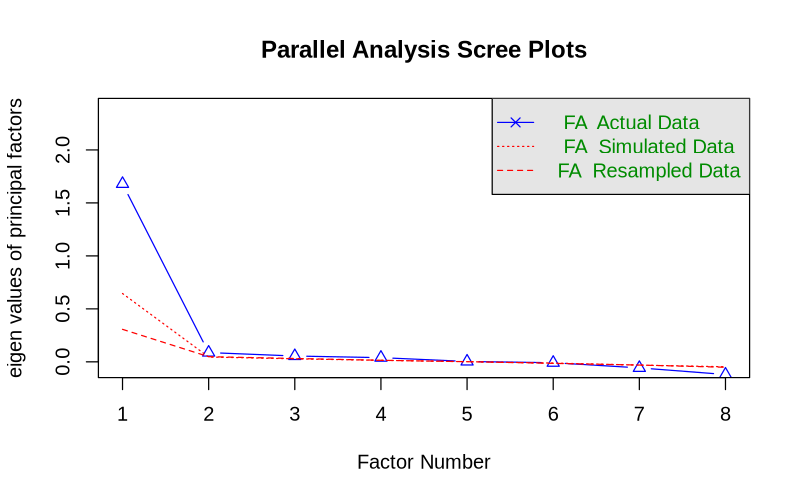

In [10]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 800, height = 500, res = 120,
    type = "cairo", family = "sans")


print(
  fa.parallel(X_books_norm, fa = "fa")
)

dev.off()
IRdisplay::display_png(file = tmp_file)


### Step 5 — EFA with Varimax Rotation, `nfactors = 2`

Store the result in `fa_books`. Print loadings with `cutoff = 0.30, sort = TRUE`.

In [11]:


fa_books <- fa(X_books_norm, nfactors = 2, rotate = "varimax", fm = "ml")

print(fa_books$loadings, cutoff = 0.30, sort = TRUE)
fa_books$Vaccounted



Loadings:
         ML2   ML1  
ChildBks 0.607      
CookBks  0.674      
ArtBks         0.993
YouthBks 0.479      
DoItYBks 0.495      
RefBks   0.426      
GeogBks  0.368      
ItalCook            

                 ML2   ML1
SS loadings    1.655 1.003
Proportion Var 0.207 0.125
Cumulative Var 0.207 0.332


,ML2,ML1
SS loadings,1.6551,1.0030
Proportion Var,0.2069,0.1254
Cumulative Var,0.2069,0.3323
Proportion Explained,0.6227,0.3773
Cumulative Proportion,0.6227,1.0000


### Question 5 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

---


## Question 6 — Module 4.1b: Conjoint Analysis (Streaming Service)

A streaming service tests three attributes:
`Price` (\$8 / \$12 / \$16), `Resolution` (HD / 4K), `Ads` (Yes / No).
A focus-group respondent rated each of the 12 profiles on a 1 (worst) – 9 (best)
scale.

**Tasks:**
1. Build the 3 × 2 × 2 = 12 profile design dataframe (with the ratings vector below) → store in `profiles.df`
2. Estimate part-worth utilities by fitting `Rating ~ Price + Resolution + Ads` → store in `cj_lm`
3. Compute the part-worths (level mean − grand mean) → store in `partworth` (a named list, one element per attribute)
4. Compute attribute importance % (range / sum of ranges × 100) → store in `attr_importance`
5. Identify the **best** and **worst** predicted profiles → store in `best_profile` and `worst_profile`
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Build the Profile Design and Add Ratings

Store in `profiles.df`. Use the ratings vector exactly as provided.

In [ ]:

profiles.df <- expand.grid(
  Price      = factor(c("$8","$12","$16"), levels = c("$8","$12","$16")),
  Resolution = factor(c("HD","4K")),
  Ads        = factor(c("Yes","No"))
)
profiles.df$Rating <- c(7, 5, 3,  9, 6,
                        8, 5, 2,  9, 7,
                        6, 4)        # 12 ratings provided

profiles.df


Price,Resolution,Ads,Rating
<fct>,<fct>,<fct>,<dbl>
$8,HD,Yes,7
$12,HD,Yes,5
$16,HD,Yes,3
$8,4K,Yes,9
$12,4K,Yes,6
$16,4K,Yes,8
$8,HD,No,5
$12,HD,No,2
$16,HD,No,9


### Step 2 — Linear Regression for Part-Worths

Store the model in `cj_lm`.

In [13]:

cj_lm <- lm(Rating ~ Price + Resolution + Ads, data = profiles.df)

summary(cj_lm)



Call:
lm(formula = Rating ~ Price + Resolution + Ads, data = profiles.df)

Residuals:
   Min     1Q Median     3Q    Max 
-2.667 -1.021  0.208  0.833  4.167 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept)     7.333      1.462    5.02   0.0015 **
Price$12       -2.250      1.602   -1.40   0.2029   
Price$16       -1.000      1.602   -0.62   0.5522   
ResolutionHD   -1.500      1.308   -1.15   0.2891   
AdsYes          0.833      1.308    0.64   0.5443   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.27 on 7 degrees of freedom
Multiple R-squared:  0.346,	Adjusted R-squared:  -0.0277 
F-statistic: 0.926 on 4 and 7 DF,  p-value: 0.5


### Step 3 — Compute Part-Worths

Store in `partworth` as a named list (one element per attribute) where each
element is a vector of (level mean − grand mean).

In [14]:
grand_mean <- mean(profiles.df$Rating)

partworth <- list()

partworth$Price <- tapply(profiles.df$Rating, profiles.df$Price, mean) - grand_mean
partworth$Resolution <- tapply(profiles.df$Rating, profiles.df$Resolution, mean) - grand_mean
partworth$Ads <- tapply(profiles.df$Rating, profiles.df$Ads, mean) - grand_mean

partworth


$Price
      $8      $12      $16 
 1.08333 -1.16667  0.08333 

$Resolution
   4K    HD 
 0.75 -0.75 

$Ads
     No     Yes 
-0.4167  0.4167

### Step 4 — Attribute Importance (%)

Store in `attr_importance` (a named numeric vector summing to ~100).

In [15]:
ranges <- sapply(partworth, function(x) max(x) - min(x))

attr_importance <- (ranges / sum(ranges)) * 100
round(attr_importance, 1)


Price Resolution        Ads 
      49.1       32.7       18.2

### Step 5 — Best and Worst Predicted Profiles

Store in `best_profile` and `worst_profile`.

In [16]:

profiles.df$Pred <- predict(cj_lm)
best_profile  <- profiles.df[which.max(profiles.df$Pred), ]
worst_profile <- profiles.df[which.min(profiles.df$Pred), ]

cat("BEST predicted profile:\n");  print(best_profile)
cat("\nWORST predicted profile:\n"); print(worst_profile)


BEST predicted profile:
  Price Resolution Ads Rating  Pred
4    $8         4K Yes      9 8.167

WORST predicted profile:
  Price Resolution Ads Rating  Pred
8   $12         HD  No      2 3.583


### Question 6 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

---


## Question 7 — Module 5.0: Cluster Analysis on EastWestAirlines

**Dataset:** `mlba::EastWestAirlinesCluster` (3,999 frequent-flyers × 12 variables)

**Inputs (X):** the 10 behavioral variables — drop `ID.` and `Award.`.

**Tasks:**
1. Load the data, drop `ID.` and `Award.` → store in `ewa.df`; standardize → store in `X_ewa_norm`
2. Compute the Euclidean distance matrix → store in `d_ewa`
3. **Hierarchical clustering with Ward's linkage** (`method = "ward.D2"`) → store in `hc_ewa`; cut at `k = 4` → store labels in `Y_ewa_hier`
4. **K-means** with `centers = 4`, `nstart = 25`, `set.seed(42)` → store in `km_ewa`; store labels in `Y_ewa_km`
5. Cross-tabulate hierarchical vs k-means cluster labels
6. Profile the k-means clusters on the **original (unstandardized)** scale → store the table in `ewa_profile`
7. Plot the k-means cluster visualization (`fviz_cluster`)
8. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load, Drop ID/Award, Standardize

Store the cleaned dataframe in `ewa.df` and the standardized matrix in `X_ewa_norm`.

In [ ]:
# YOUR CODE HERE — delete this comment when you add your code
# Required objects: ewa.df, X_ewa_norm

ewa.df      <- NULL    # replace NULL with your code
X_ewa_norm  <- NULL    # replace NULL with your code

cat("n =", nrow(ewa.df), " p =", ncol(ewa.df), "\n")


### Step 2 — Euclidean Distance Matrix

Store in `d_ewa`.

In [ ]:
# YOUR CODE HERE — delete this comment when you add your code
# Required object: d_ewa

d_ewa <- NULL    # replace NULL with your code


### Step 3 — Hierarchical Clustering (Ward) and Cut at k = 4

Store the hclust object in `hc_ewa` and the cluster labels in `Y_ewa_hier`.

In [ ]:
# YOUR CODE HERE — delete this comment when you add your code
# Required objects: hc_ewa, Y_ewa_hier

hc_ewa     <- NULL    # replace NULL with your code   (method = "ward.D2")
Y_ewa_hier <- NULL    # replace NULL with your code   (cutree at k = 4)

table(Y_ewa_hier)


### Step 3b — Plot the Ward Dendrogram (with k = 4 boxes)

Use the cairo-PNG wrapper. Draw `plot(hc_ewa, labels = FALSE, ...)` and
overlay `rect.hclust(hc_ewa, k = 4, border = "red")`.

In [ ]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 1000, height = 600, res = 120,
    type = "cairo", family = "sans")

# YOUR CODE HERE — delete this comment when you add your code


NULL    # replace NULL with your plot(...) call
NULL    # replace NULL with your rect.hclust(...) call

dev.off()
IRdisplay::display_png(file = tmp_file)


### Step 4 — K-Means (k = 4)

Store the kmeans object in `km_ewa` and the labels in `Y_ewa_km`.

In [ ]:
set.seed(42)
# YOUR CODE HERE — delete this comment when you add your code
# Required objects: km_ewa, Y_ewa_km

km_ewa   <- NULL    # replace NULL with your code   (centers = 4, nstart = 25)
Y_ewa_km <- NULL    # replace NULL with your code

table(Y_ewa_km)


### Step 5 — Cross-Tabulate Hierarchical vs K-Means

In [ ]:
# YOUR CODE HERE — delete this comment when you add your code
# Print a cross-tabulation of Y_ewa_hier (rows) vs Y_ewa_km (columns).

NULL    # replace NULL with your code


### Step 6 — Cluster Profile (Original Scale)

Store the per-cluster mean table in `ewa_profile`.

In [ ]:
# YOUR CODE HERE — delete this comment when you add your code
# Required object: ewa_profile


ewa_profile <- NULL    # replace NULL with your code
ewa_profile


### Step 7 — K-Means Cluster Visualization

In [ ]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 600, res = 120,
    type = "cairo", family = "sans")

# YOUR CODE HERE — delete this comment when you add your code
# Build the fviz_cluster(...) plot inside print(...).

print(
  NULL    # replace NULL with your fviz_cluster(km_ewa, data = X_ewa_norm, ...) call
)

dev.off()
IRdisplay::display_png(file = tmp_file)


### Question 7 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

---


## Question 8 — Module 5.1: Linear Discriminant Analysis on Banks

**Dataset:** `mlba::Banks` (20 banks × 5 variables)

**Inputs (X):** `TotCap.Assets`, `TotExp.Assets`, `TotLns.Lses.Assets`.

**Output (Y):** `Financial.Condition` recoded as a factor with labels
`c("Strong", "Weak")` (levels `0 = Strong, 1 = Weak`).

**Tasks:**
1. Load the data, drop `Obs`, recode `Financial.Condition` to a factor with labels `c("Strong","Weak")` → store in `banks.df`; create `X_banks` (3 predictors) and `Y_banks` (target factor)
2. Fit an **LDA**: `Financial.Condition ~ .` → store in `lda_banks`
3. Predict on the full data (n = 20 is too small to hold out) → store predicted classes in `Y_banks_pred`, the `caret::confusionMatrix` in `cm_banks`, and the overall accuracy in `accuracy_banks`
4. Predict the financial condition of a new bank with `TotCap.Assets = 8.0`, `TotExp.Assets = 0.11`, `TotLns.Lses.Assets = 0.55` → store the new observation in `new_bank` and the prediction in `pred_new_bank`
5. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load and Prepare Data

Store the cleaned dataframe in `banks.df`, predictors in `X_banks`, target in `Y_banks`.

In [ ]:
# YOUR CODE HERE — delete this comment when you add your code
# Required objects: banks.df, X_banks, Y_banks

banks.df <- NULL    # replace NULL with your code   (factor labels c("Strong","Weak"); drop Obs)
X_banks  <- NULL    # replace NULL with your code   (3 numeric predictors)
Y_banks  <- NULL    # replace NULL with your code   (target factor)

cat("Class balance:\n"); print(table(Y_banks))
banks.df


### Step 2 — Fit the LDA Model

Store in `lda_banks`.

In [ ]:
# YOUR CODE HERE — delete this comment when you add your code
# Required object: lda_banks

lda_banks <- NULL    # replace NULL with your code
lda_banks


### Step 3 — Confusion Matrix on the Full Data

Store predictions in `Y_banks_pred`, confusion matrix in `cm_banks`, accuracy in `accuracy_banks`.

In [ ]:
# YOUR CODE HERE — delete this comment when you add your code
# Required objects: Y_banks_pred, cm_banks, accuracy_banks

Y_banks_pred   <- NULL    # replace NULL with your code
cm_banks       <- NULL    # replace NULL with your code   (caret::confusionMatrix)
accuracy_banks <- NULL    # replace NULL with your code

cm_banks
cat("Overall accuracy:", round(accuracy_banks, 4), "\n")


### Step 4 — Predict for a New Bank

Store the new observation in `new_bank` and the prediction in `pred_new_bank`.

In [ ]:
# YOUR CODE HERE — delete this comment when you add your code
# Required objects: new_bank, pred_new_bank

new_bank      <- NULL    # replace NULL with your code   (data.frame with the 3 predictors)
pred_new_bank <- NULL    # replace NULL with your code   (predict(lda_banks, new_bank))

cat("Predicted class:", as.character(pred_new_bank$class), "\n")
cat("Posterior probabilities:\n"); print(round(pred_new_bank$posterior, 4))


### Question 8 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

---


## Submission Checklist

Before submitting, verify that:

- [ ] All `# YOUR CODE HERE — delete this comment when you add your code` comments have been **removed**
- [ ] All `NULL` placeholders have been **replaced** with working code
- [ ] The notebook **runs top-to-bottom without errors** (Kernel → Restart & Run All)
- [ ] All eight `*Your answer here*` markdown cells have been replaced with your written interpretation
- [ ] Variable / object names match the **Required object names** table at the top of the notebook
